Columns: Index(['city_mpg', 'class', 'combination_mpg', 'cylinders', 'displacement',
       'drive', 'fuel_type', 'highway_mpg', 'make', 'model', 'transmission',
       'year'],
      dtype='object')

Model Performance:
Mean Squared Error (MSE): 10.361236243122036
R² Score: 0.6024462558448971


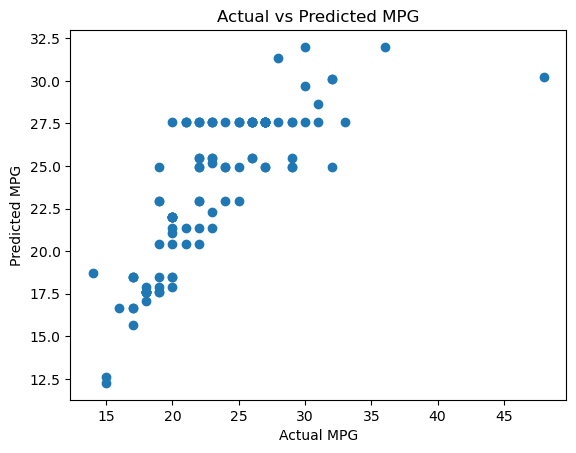

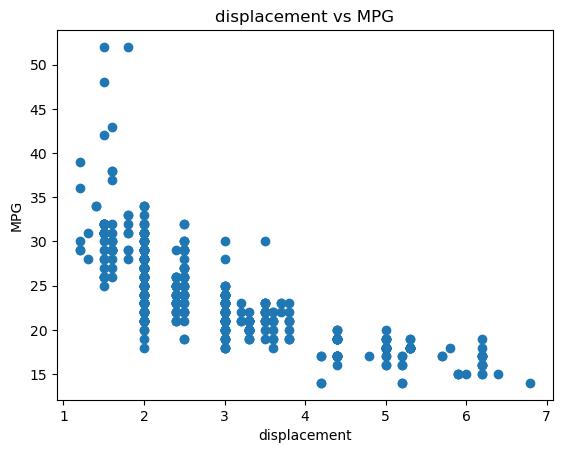

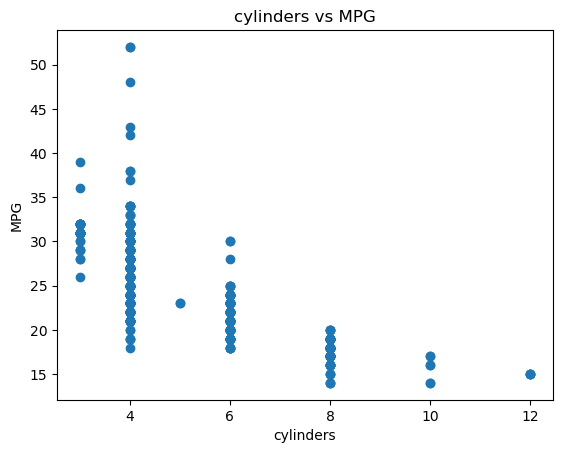

In [6]:
# 🔹 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 2. Load Dataset
df = pd.read_csv("car_data.csv")

# 🔹 3. Clean Column Names
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)

# 🔹 4. Select Features and Target (NO DATA LEAKAGE)
features = ['displacement', 'cylinders']   # only independent features
target = 'combination_mpg'

X = df[features]
y = df[target]

# 🔹 5. Handle Missing Values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# 🔹 6. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 7. Polynomial Features (degree = 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 🔹 8. Build Model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 🔹 9. Predictions
y_pred = model.predict(X_test_poly)

# 🔹 10. Evaluation
print("\nModel Performance:")
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# 🔹 11. Actual vs Predicted Plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.show()

# 🔹 12. Feature vs Target Scatter Plots
for col in features:
    plt.figure()
    plt.scatter(df[col], df[target])
    plt.xlabel(col)
    plt.ylabel("MPG")
    plt.title(f"{col} vs MPG")
    plt.show()